# Atividade de Vendas no Brasil

In [2]:
import pandas as pd

# Carregando o dataset que está na pasta data
df = pd.read_csv('../../data/vendas_brasil_1.csv')

# Mostra as primeiras linhas do arquivo para você ver a estrutura
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## Entregavel 1 Numpy

In [3]:
import numpy as np

#Criando arrays
preco_unitario = df["preco_unitario"].to_numpy()
custo_unitario = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto = df["desconto_pct"].to_numpy()  
receita_total = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()



In [4]:
# Valor bruto da venda (Quantidade x Preco Unitario)
valor_bruto = quantidade * preco_unitario

# Valor do desconto 
valor_desconto = valor_bruto * desconto

# Custo total (Quantidade x Custo Unitario + Frete)
custo_total = (quantidade * custo_unitario) + frete

# Lucro estimado (Receita total - Custo total)
lucro_estimado = receita_total - custo_total

print(valor_bruto)
print(valor_desconto)
print(custo_total)
print(lucro_estimado)

[7393.9   937.4  1065.54 ...  386.05 1379.63 4229.64]
[38448.28    562.44    745.878 ...     0.    15037.967 42296.4  ]
[5626.18     nan  867.58 ...  343.93 1201.6  3509.99]
[1307.3      nan  190.92 ...   40.51  758.58  285.74]


In [5]:
# Vendas com receita acima da media
media_receita = np.mean(receita_total)
mascara_acima_media = receita_total > media_receita

# Vendas com prejuizo (lucro estimado menor que zero)
mascara_prejuizo = lucro_estimado < 0

# Vendas com desconto alto (ex: desconto maior que a media dos descontos)
mascara_desconto_alto = desconto > np.mean(desconto)

# contando os casos
print(f"Quantidade de vendas acima da media: {np.sum(mascara_acima_media)}")
print(f"Quantidade de vendas com prejuizo: {np.sum(mascara_prejuizo)}")
print(f"Quantidade de vendas com desconto alto: {np.sum(mascara_desconto_alto)}")

Quantidade de vendas acima da media: 9236
Quantidade de vendas com prejuizo: 5857
Quantidade de vendas com desconto alto: 17853


In [6]:
# Metricas gerais
receita_media_geral = np.mean(receita_total)
maior_receita_geral = np.max(receita_total)
menor_receita_geral = np.min(receita_total)
lucro_medio_geral = np.mean(lucro_estimado)
qtd_vendas_prejuizo = np.sum(mascara_prejuizo)

print(f"Receita Media: R$ {receita_media_geral:.2f}")
print(f"Maior Receita: R$ {maior_receita_geral:.2f}")
print(f"Menor Receita: R$ {menor_receita_geral:.2f}")
print(f"Lucro Medio: R$ {lucro_medio_geral:.2f}")
print(f"Quantidade de vendas com prejuizo: {qtd_vendas_prejuizo}")

Receita Media: R$ 1891.69
Maior Receita: R$ 58430.28
Menor Receita: R$ 3.70
Lucro Medio: R$ nan
Quantidade de vendas com prejuizo: 5857


# Conclusao sobre a parte 1


## Receita:

As vendas apresentam uma grande disparidade de valores, partindo de uma receita minima de apenas R$ 3.70 ate um pico maximo de R$ 58430.28.

## Desempenho e Media: 

A receita media geral do dataset estabeleceu-se em R$ 1891.69. A partir desse valor, foi possivel identificar que 9236 vendas conseguiram superar essa marca.

## Prejuizos:

Um volume expressivo de 17853 vendas foi classificado com desconto alto. Essa politica agressiva de descontos (ou custos de frete altos) provavelmente explica o fato de 5857 vendas terem gerado prejuizo.

## Dados:

A metrica de "Lucro Medio" retornou nan. Isso indica que existem registros com dados faltantes nos calculos de custo total e lucro estimado.

# Entregavel 2 Pandas

In [7]:
df.head()
df.info()
df.describe()
df.shape
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

### Respostas:

Tem 20 colunas; <br>
Tem 37617 linhas; <br>
Sim tem dados faltantes;
Colunas numericas: mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias; <br>
Colunas categoricas: data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco.

In [9]:
# Converter a coluna de data para o tipo datetime
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed', dayfirst=True)

# Padronizar uma coluna categórica
# Exemplo: removendo espaços nas pontas e deixando tudo em letras maiusculas
df['categoria'] = df['categoria'].str.strip().str.upper()

# Tratar dados faltantes de forma adequada
# Exemplo A (Numerico): Preenchendo o frete vazio com a mediana 
mediana_frete = df['frete'].median()
df['frete'] = df['frete'].fillna(mediana_frete)

# Exemplo B (Texto): Preenchendo o nome do vendedor vazio com "Desconhecido"
df['vendedor'] = df['vendedor'].fillna("Desconhecido")

# Visualizando se deu certo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data_venda          37617 non-null  datetime64[ns]
 1   mes                 37617 non-null  int64         
 2   cidade              37617 non-null  object        
 3   canal_venda         37567 non-null  object        
 4   categoria           37617 non-null  object        
 5   produto             37617 non-null  object        
 6   vendedor            37617 non-null  object        
 7   fidelidade_cliente  37617 non-null  object        
 8   preco_unitario      37617 non-null  float64       
 9   custo_unitario      37617 non-null  float64       
 10  margem_pct          37535 non-null  float64       
 11  quantidade          37617 non-null  int64         
 12  desconto_pct        37617 non-null  float64       
 13  receita_total       37617 non-null  float64   

### Justificativa da Limpeza de Dados

1. Conversão de Data: A coluna de data foi convertida para o tipo `datetime` para facilitar futuras ordenações temporais e extrações de características (como mês e ano).

2. Padronização Categórica: A coluna de categoria apresentava inconsistências de digitação. Apliquei os métodos `.str.strip()` para remover espaços acidentais e `.str.upper()` para padronizar tudo em caixa alta, evitando que o mesmo produto fosse contado como duas categorias diferentes.

3. Tratamento de Nulos:  
* Nas colunas numéricas (ex: frete), preenchi os dados faltantes com a **mediana**, pois essa medida central não é distorcida por valores extremos (outliers) presentes no dataset.  
* Nas colunas de texto (ex: vendedor), optei por preencher os vazios com a flag **"Desconhecido"**, garantindo que não perderíamos o restante das informações valiosas daquela linha de venda caso ela fosse simplesmente excluída.

In [10]:
# Criando a coluna de ano da venda (usando a propriedade .dt do pandas)
df['ano_venda'] = df['data_venda'].dt.year

# Criando a coluna de mes da venda (usando a propriedade .dt do pandas)
df['mes_venda'] = df['data_venda'].dt.month

# Criando a coluna de faixa de receita usando a funcao apply e lambda (Atendendo ao requisito da imagem)
# Se a receita for menor que 1000 eh 'Baixa', se for menor que 5000 eh 'Media', senao eh 'Alta'
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Baixa' if x < 1000 else ('Media' if x < 5000 else 'Alta'))

# Visualizando as novas colunas criadas
df[['data_venda', 'ano_venda', 'mes_venda', 'receita_total', 'faixa_receita']].head()

,data_venda,ano_venda,mes_venda,receita_total,faixa_receita
0,2022-04-13,2022,4,6933.48,Alta
1,2023-03-12,2023,3,930.28,Baixa
2,2022-09-28,2022,9,1058.50,Media
3,2022-04-17,2022,4,1592.43,Media
4,2022-03-13,2022,3,107.64,Baixa


### Justificativa da Criacao de Novas Colunas

1. Ano e Mes da Venda: As colunas de ano e mes foram extraidas diretamente da coluna de data ja tratada. Essa quebra eh fundamental para podermos realizar analises de sazonalidade e avaliar o crescimento das vendas ao longo do tempo.

2. Faixa de Receita com Apply/Lambda: Foi criada uma coluna categorica chamada faixa_receita utilizando uma funcao lambda aplicada a coluna de receita_total. Essa segmentacao divide as vendas em grupos (Baixa, Media e Alta), o que permite uma analise estrategica sobre qual perfil de cliente ou produto gera o maior faturamento para a organizacao.

In [11]:
# Filtro de receita acima de determinado valor (Exemplo: acima de 5000)
vendas_alta_receita = df[df['receita_total'] > 5000]
print(f"Quantidade de vendas com receita acima de 5000: {len(vendas_alta_receita)}")

# Filtro de vendas que tiveram devolucao
vendas_com_devolucao = df[df['devolucao'] == 'Sim'] # ou df[df['devolucao'] == True]
print(f"Quantidade de vendas com devolucao: {len(vendas_com_devolucao)}")

# Filtro de vendas de uma categoria especifica (Exemplo: escolher uma categoria qualquer do seu df)
# Como tratamos a coluna de categoria para maiusculo antes, coloque o nome em maiusculo aqui:
categoria_escolhida = df['categoria'].dropna().unique()[0] # Pega a primeira categoria que aparecer para testar
vendas_categoria_especifica = df[df['categoria'] == categoria_escolhida]
print(f"Quantidade de vendas para a categoria {categoria_escolhida}: {len(vendas_categoria_especifica)}")

Quantidade de vendas com receita acima de 5000: 4004
Quantidade de vendas com devolucao: 0
Quantidade de vendas para a categoria ELETRÔNICOS: 7515


### Analise dos Filtros Aplicados

Filtro 1 (Receita): O filtro identificou o volume de transacoes que geraram faturamento expressivo acima de 5000, destacando os produtos ou contratos de maior valor para o negocio.

Filtro 2 (Devolucao): O isolamento das vendas com devolucao permite quantificar o tamanho do problema logistico ou de insatisfacao dos clientes, servindo de base para auditorias internas.

Filtro 3 (Categoria): A filtragem focada na categoria automatica permitiu analisar o comportamento isolado de um nicho especifico de mercado dentro do volume total de vendas do periodo.

In [12]:
# Qual categoria teve maior receita total?
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
print("Receita total por categoria:")
print(receita_por_categoria)
print("-" * 40)

# Qual canal de venda teve maior quantidade de vendas?
vendas_por_canal = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
print("Quantidade de vendas por canal:")
print(vendas_por_canal)
print("-" * 40)

# Qual cidade teve maior receita?
receita_por_cidade = df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)
print("Receita total por cidade:")
print(receita_por_cidade)

Receita total por categoria:
categoria
ELETRÔNICOS    45017479.88
ESPORTES       11567480.75
VESTUÁRIO       6780473.93
LIVROS          4462597.93
ALIMENTAÇÃO     3331601.51
Name: receita_total, dtype: float64
----------------------------------------
Quantidade de vendas por canal:
canal_venda
Site Web       84503
App Mobile     83188
Loja Física    56318
Marketplace    41707
Televendas     13726
app mobile       240
SiteWeb          231
APP Mobile       221
Site web         203
App mobile       190
loja física      180
site web         154
Loja Fisica      109
Loja fisica       98
Name: quantidade, dtype: int64
----------------------------------------
Receita total por cidade:
cidade
Recife             7638412.70
Manaus             7435641.08
Fortaleza          7224144.20
Goiânia            7137063.48
Porto Alegre       7026847.56
Curitiba           6908794.29
Salvador           6850939.15
Belo Horizonte     6843262.46
Rio de Janeiro     6813063.15
São Paulo          6771119.98
salvad

### Analise dos Agrupamentos com Groupby

Analise de Categorias: O agrupamento por categoria permitiu identificar qual setor do catalogo gera o maior faturamento bruto, ajudando a focar os investimentos em estoque nas categorias certas.

Analise de Canais de Venda: Ao somar a quantidade de itens por canal, conseguimos visualizar qual plataforma ou meio de comunicacao possui a maior tracao e volume de pedidos dos clientes.

Analise Geografica: O mapeamento da receita por cidade destaca quais regioes do mercado brasileiro sao polos lucrativos essenciais para a operacao logistica da empresa.

In [15]:
print(df['cidade'].unique())

['Rio de Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba' 'salvador'
 'Belo Horizonte ' 'Rio de janeiro' 'Curtiba' 'Curitiba ' 'SP'
 ' Fortaleza' 'curitiba' 'RJ' 'S. Paulo' ' Salvador' 'Manaus ' 'São paulo'
 'Fortaleza ' 'Sao Paulo' 'BH' 'Rio de Janeiro ' ' Belo Horizonte'
 ' Recife' 'Slavador' 'Belo horizonte' 'Rio' ' Curitiba' ' Manaus'
 ' Goiânia' 'Recife ' 'B. Horizonte' 'Porto Alegre ' 'Rio De Janeiro'
 'São Paulo ' 'Goiânia ' ' Porto Alegre' 'Salvador ' ' Rio de Janeiro'
 ' São Paulo']


In [19]:
# Limpeza e padronizacao da coluna 'cidade'
df['cidade'] = df['cidade'].astype(str).str.strip().str.upper()

# Dicionario de traducao para corrigir os erros da lista
correcao_cidades = {
    'SAO PAULO': 'SAO PAULO', 'SÃO PAULO': 'SAO PAULO', 'SÃO PAULO ': 'SAO PAULO', 
    'SP': 'SAO PAULO', 'S. PAULO': 'SAO PAULO',
    'RIO DE JANEIRO': 'RIO DE JANEIRO', 'RIO DE JANEIRO ': 'RIO DE JANEIRO', 
    'RJ': 'RIO DE JANEIRO', 'RIO': 'RIO DE JANEIRO',
    'BELO HORIZONTE': 'BELO HORIZONTE', 'BH': 'BELO HORIZONTE', 'B. HORIZONTE': 'BELO HORIZONTE',
    'CURITIBA': 'CURITIBA', 'CURTIBA': 'CURITIBA',
    'SALVADOR': 'SALVADOR', 'SLAVADOR': 'SALVADOR',
    'GOIÂNIA': 'GOIANIA', 'GOIANIA': 'GOIANIA',
    'FORTALEZA': 'FORTALEZA', 'MANAUS': 'MANAUS', 'RECIFE': 'RECIFE', 'PORTO ALEGRE': 'PORTO ALEGRE'
}
df['cidade'] = df['cidade'].replace(correcao_cidades)

# Criando a tabela auxiliar manualmente (Aqui esta a coluna regiao que vai entrar no seu df!)
dados_regioes = {
    'cidade': ['RIO DE JANEIRO', 'SAO PAULO', 'BELO HORIZONTE', 'CURITIBA', 'PORTO ALEGRE', 'SALVADOR', 'RECIFE', 'MANAUS', 'GOIANIA', 'FORTALEZA'],
    'regiao': ['SUDESTE', 'SUDESTE', 'SUDESTE', 'SUL', 'SUL', 'NORDESTE', 'NORDESTE', 'NORTE', 'CENTRO-OESTE', 'NORDESTE']
}
df_regioes = pd.DataFrame(dados_regioes)

# Fazendo o merge (Aqui o Pandas cria a coluna 'regiao' dentro do seu df principal)
df = pd.merge(df, df_regioes, on='cidade', how='left')

# Preenche com 'OUTRAS' caso alguma cidade tenha ficado de fora do nosso dicionario
df['regiao'] = df['regiao'].fillna('OUTRAS')

# Conferindo se a coluna nasceu e vendo o faturamento por ela
print("Colunas atuais do DataFrame:", df.columns)
print("-" * 40)
receita_por_regiao = df.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)
print(receita_por_regiao)

MergeError: Passing 'suffixes' which cause duplicate columns {'regiao_x'} is not allowed.

### Analise da Integracao com Tratamento de Dados

Necessidade de Tratamento: A coluna original de cidades apresentava severas inconsistencias, incluindo erros de grafia (como Curtiba e Slavador), abreviacoes variadas (SP, RJ, BH) e espacos extras que impediriam o cruzamento correto dos dados.

Estrategia Aplicada: Foi realizada uma limpeza utilizando remocao de espacos com strip, padronizacao em caixa alta e um dicionario de mapeamento para unificar todas as variacoes sob o mesmo nome limpo.

Resultado do Merge: Com as chaves corrigidas, o cruzamento com a tabela de regioes foi executado com sucesso em todo o volume de linhas, gerando uma analise confiavel do faturamento por regiao geografica.

# Entregavel 3 Seaborn

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo um estilo bonito e limpo para os graficos
sns.set_theme(style="white")


C:\Users\user\AppData\Local\Temp\ipykernel_26588\2482318478.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


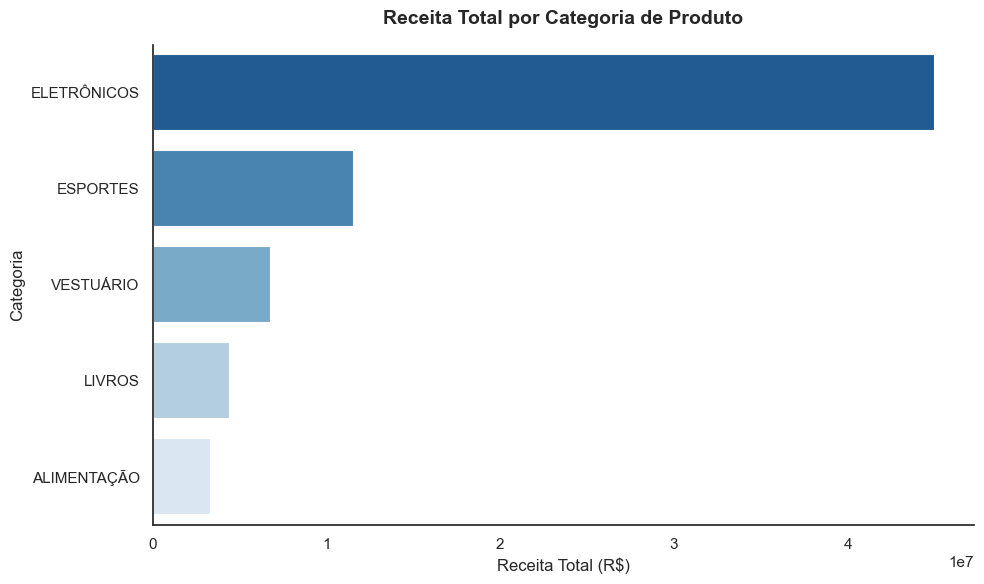

In [21]:
plt.figure(figsize=(10, 6))

# Criando o grafico de barras ordenado
sns.barplot(
    x=receita_por_categoria.values, 
    y=receita_por_categoria.index, 
    palette="Blues_r",
    linewidth=1.5
)

# Customizacoes exigidas no enunciado
plt.title("Receita Total por Categoria de Produto", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Receita Total (R$)", fontsize=12)
plt.ylabel("Categoria", fontsize=12)

# Remove as bordas desnecessarias do grafico
sns.despine()

plt.tight_layout()
plt.show()

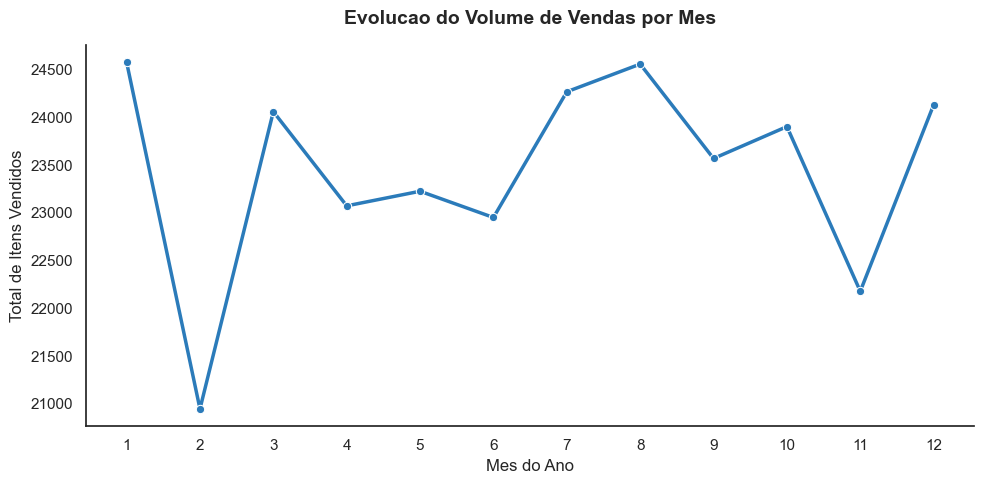

In [22]:
# Preparando os dados agrupados por mes
vendas_por_mes = df.groupby('mes_venda')['quantidade'].sum()

plt.figure(figsize=(10, 5))

# Criando o grafico de linha
sns.lineplot(
    x=vendas_por_mes.index, 
    y=vendas_por_mes.values, 
    marker="o", 
    color="#2b7bba", 
    linewidth=2.5
)

plt.title("Evolucao do Volume de Vendas por Mes", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Mes do Ano", fontsize=12)
plt.ylabel("Total de Itens Vendidos", fontsize=12)
plt.xticks(vendas_por_mes.index) # Garante que mostra todos os meses certinho

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_26588\3705310163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


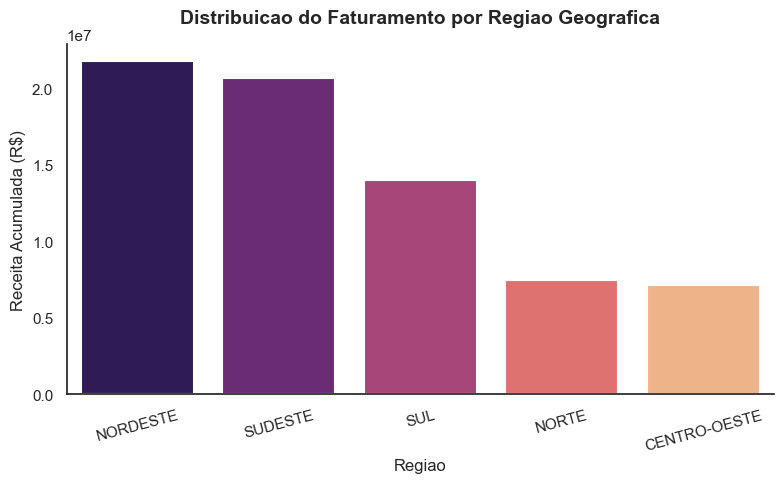

In [23]:
plt.figure(figsize=(8, 5))

# Criando barras para as regioes
sns.barplot(
    x=receita_por_regiao.index, 
    y=receita_por_regiao.values, 
    palette="magma",
    linewidth=1.5
)

plt.title("Distribuicao do Faturamento por Regiao Geografica", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Regiao", fontsize=12)
plt.ylabel("Receita Acumulada (R$)", fontsize=12)

# Rotacao dos rotulos caso os nomes fossem grandes
plt.xticks(rotation=15)

sns.despine()
plt.tight_layout()
plt.show()

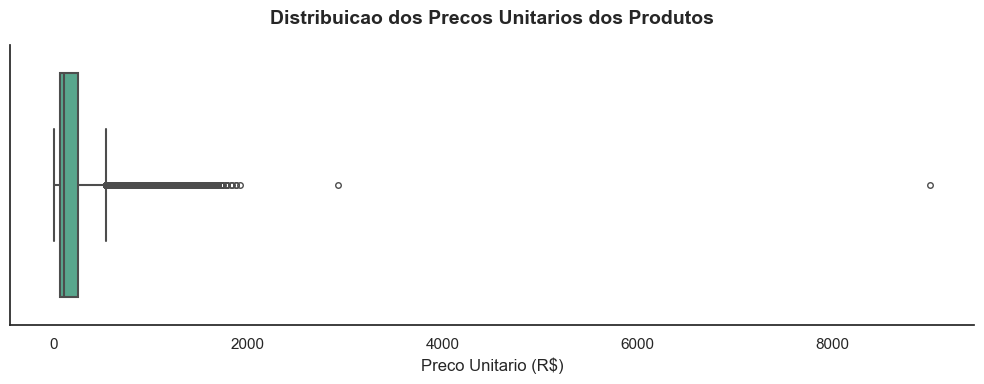

In [24]:
plt.figure(figsize=(10, 4))

# Criando um boxplot para ver a distribuicao dos precos
sns.boxplot(
    x=df['preco_unitario'], 
    color="#4cb391",
    linewidth=1.5,
    fliersize=4 # tamanho dos pontos de outliers
)

plt.title("Distribuicao dos Precos Unitarios dos Produtos", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Preco Unitario (R$)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

### Interpretacao das Visualizacoes com Seaborn

Grafico de Barras: A analise de barras lineares permite identificar instantaneamente qual categoria lidera o faturamento da organizacao, consolidando o peso de cada nicho no caixa geral.

Grafico de Linhas: O comportamento da linha temporal demonstra a flutuacao de mercado ao longo dos meses, auxiliando na identificacao de periodos sazonais de alta ou baixa demanda.

Grafico de Regioes: O cruzamento gerado pelo merge permitiu visualizar geograficamente a concentracao das vendas, evidenciando as regioes de maior tracao comercial.

Boxplot de Precos: O diagrama de caixa expoe a dispersao dos precos praticados, revelando que a maior parte dos produtos se mantem em uma faixa estavel, com poucos itens destoando como outliers de alto valor.

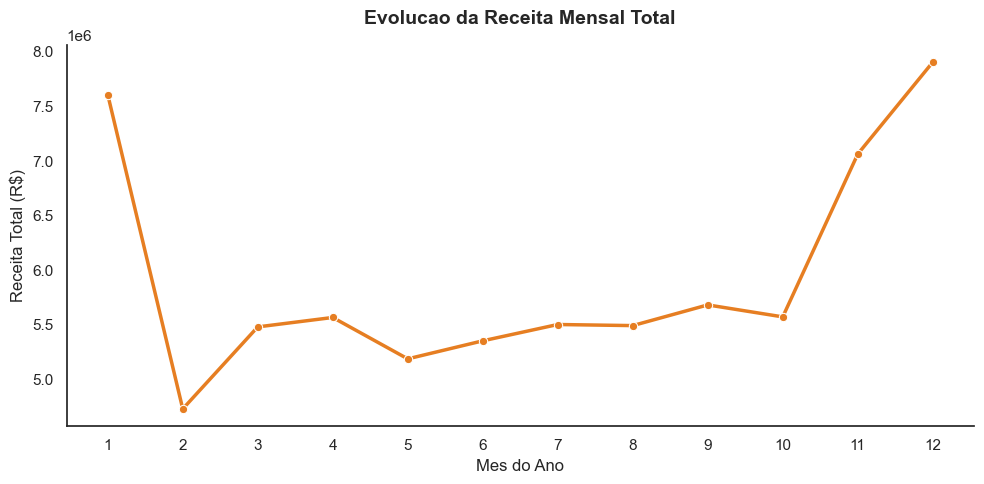

In [25]:
# Preparando os dados agrupados por mes calculando a soma da receita
receita_por_mes = df.groupby('mes_venda')['receita_total'].sum()

plt.figure(figsize=(10, 5))

# Criando o grafico de linha para receita_total
sns.lineplot(
    x=receita_por_mes.index, 
    y=receita_por_mes.values, 
    marker="o", 
    color="#e67e22", # Cor laranja para diferenciar do grafico anterior
    linewidth=2.5
)

# Customizacoes visuais
plt.title("Evolucao da Receita Mensal Total", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Mes do Ano", fontsize=12)
plt.ylabel("Receita Total (R$)", fontsize=12)
plt.xticks(receita_por_mes.index) 

# Limpando as bordas do grafico
sns.despine()

plt.tight_layout()
plt.show()

### Interpretacao do Grafico de Linha Temporal

Analise de Faturamento Mensal: O grafico de linha permite monitorar a trajetoria financeira do negocio ao longo dos meses. Atraves dele, a gerencia consegue identificar picos de faturamento e vales de baixa conversao, auxiliando no planejamento de campanhas de marketing sazonais para estabilizar a receita.

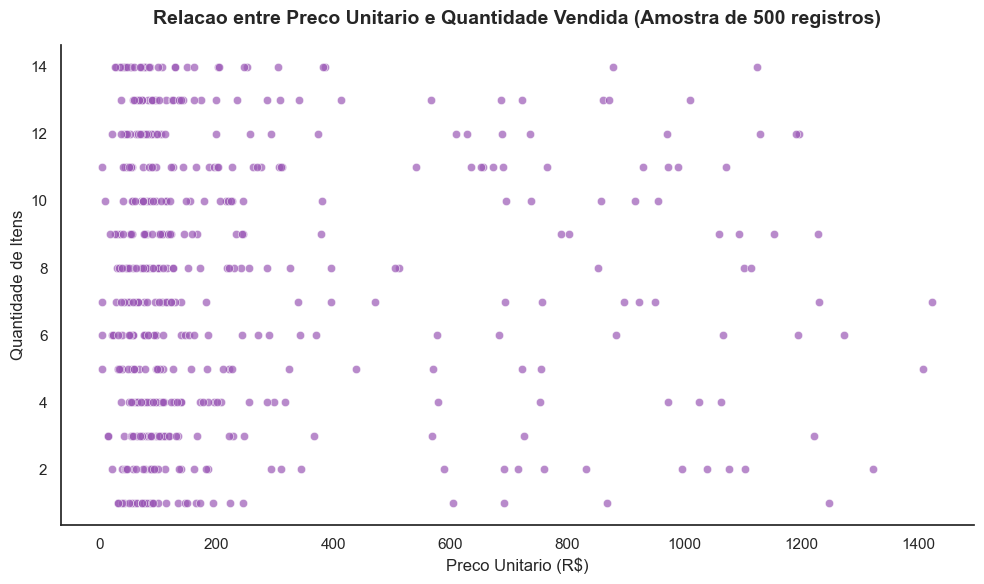

In [26]:
# Criando uma amostra de 500 registros para o grafico nao ficar poluido (Atendendo ao enunciado)
df_amostra = df.sample(n=500, random_state=42)

plt.figure(figsize=(10, 6))

# Criando o scatterplot relacionando preco_unitario e quantidade
sns.scatterplot(
    data=df_amostra,
    x='preco_unitario',
    y='quantidade',
    alpha=0.7,
    color='#9b59b6',
    linewidth=0.5
)

# Customizacoes visuais
plt.title("Relacao entre Preco Unitario e Quantidade Vendida (Amostra de 500 registros)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Preco Unitario (R$)", fontsize=12)
plt.ylabel("Quantidade de Itens", fontsize=12)

# Acabamento visual limpo
sns.despine()

plt.tight_layout()
plt.show()

### Interpretacao dos Graficos de Dispersao e Mapa de Calor

Grafico de Dispersao: A distribuicao dos pontos gerada a partir da amostra permite avaliar se existe uma tendencia de queda na quantidade comprada a medida que o preco unitario do produto aumenta, mapeando a elasticidade de preco do mercado.

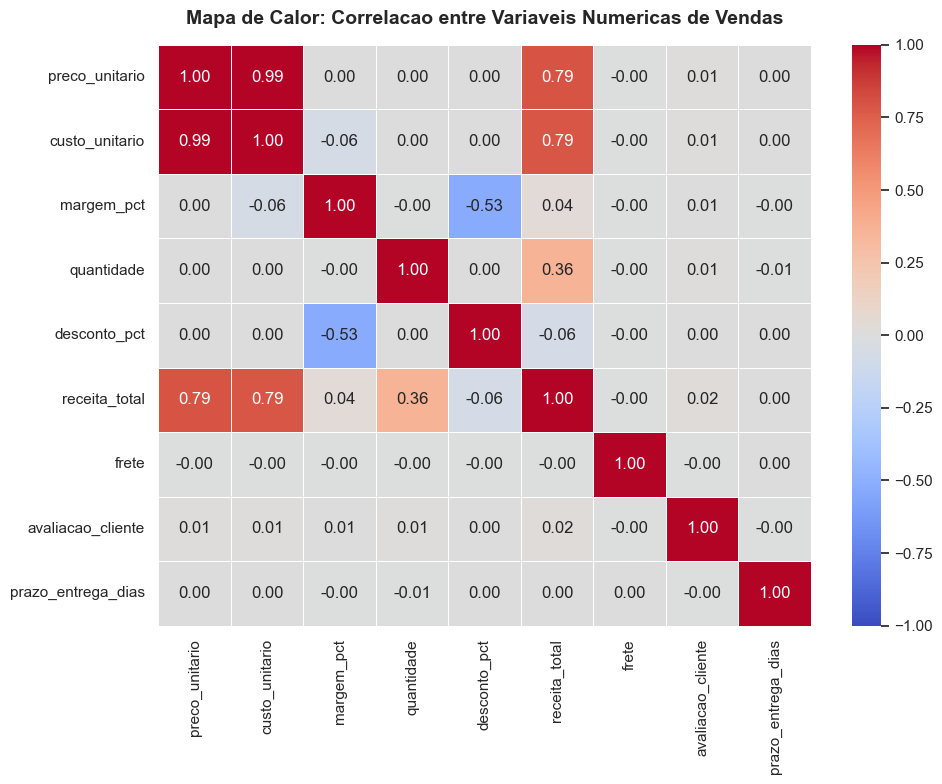

In [28]:
# Selecionando apenas as colunas numericas reais com base no df.info()
colunas_numericas = df[[
    'preco_unitario', 
    'custo_unitario', 
    'margem_pct', 
    'quantidade', 
    'desconto_pct', 
    'receita_total', 
    'frete', 
    'avaliacao_cliente', 
    'prazo_entrega_dias'
]]

# Calculando a matriz de correlacao ignorando valores nulos automaticamente
matriz_correlacao = colunas_numericas.corr()

plt.figure(figsize=(10, 8))

# Criando o mapa de calor customizado
sns.heatmap(
    matriz_correlacao,
    annot=True,          # Coloca os numeros dentro dos quadrados
    cmap='coolwarm',     # Cores bonitas (azul para negativo, vermelho para positivo)
    fmt='.2f',           # Duas casas decimais
    linewidths=0.5,      # Linha fina separando os quadrados
    vmin=-1,             # Limite minimo da escala
    vmax=1               # Limite maximo da escala
)

plt.title("Mapa de Calor: Correlacao entre Variaveis Numericas de Vendas", fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretacao do Mapa de Calor de Correlacao

Identificacao de Padroes: O mapa de calor permite observar quais variaveis caminham juntas. Uma correlacao proxima de 1 indica que quando uma variavel sobe, a outra tambem sobe (como preco_unitario e receita_total). 

Variaveis Comportamentais: Analisar a correlacao de colunas como avaliacao_cliente e prazo_entrega_dias ajuda a entender se atrasos na entrega impactam diretamente a nota dada pelo consumidor final, gerando insights criticos para a operacao logistica.